In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#simpeg Imports -- For forward problem
# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg import maps

# discretize functionality
from discretize import TensorMesh, TreeMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import tarfile
from pathlib import Path

mpl.rcParams.update({"font.size": 14}) #(No Idea..)

#Simpeg imports -- Not for forward problem
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

save_output = False  # Optional, (No Idea..)

#Fix path to data directory
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "raw"

### Read in data
We have four data files:
- obs.mag
- sus.mod
- sus.msh
- topo.dat

obs.mag is five columns organized as the following (containing total field oberservations):

X       Y       Z       DATA_VALUE    ERROR

sus.mod is one column of susceptibiity values

sus.msh decribes the tensor mesh

topo.dat is three columns, describing the topography as such:

X       Y       Z 

In [2]:
def read_obs_mag(filename):
    data = np.loadtxt(DATA_DIR / filename, skiprows=3)

    df = pd.DataFrame(data, columns=["X", "Y", "Z", "MAG", "ERR"])
    return df

def read_topo(filename):
    data = np.loadtxt(DATA_DIR / filename, skiprows=1)

    df = pd.DataFrame(data, columns=["X", "Y", "Z"])
    return df

def read_model(filename):
    data = np.loadtxt(DATA_DIR / filename)

    df = pd.DataFrame(data, columns=['sus'])
    return df

def read_tensor_mesh(file):
    with open(file, "r") as f:
        lines = [l.strip() for l in f if l.strip()]

    nx, ny, nz = map(int, lines[0].split())
    x0, y0, z0 = map(float, lines[1].split())

    def parse(line):
        n, v = line.split("*")
        return int(n), float(v)

    nx2, dx = parse(lines[2])
    ny2, dy = parse(lines[3])
    nz2, dz = parse(lines[4])

    assert (nx, ny, nz) == (nx2, ny2, nz2)

    return {
        "nx": nx, "ny": ny, "nz": nz,
        "x0": x0, "y0": y0, "z0": z0,
        "dx": dx, "dy": dy, "dz": dz
    }


In [3]:
observations = read_obs_mag("obs.mag")
topography = read_topo("topo.dat")
model = read_model("sus.mod")
mesh_data = read_tensor_mesh(DATA_DIR / "sus.msh")

In [4]:
print(observations.shape)
print(topography.shape)
print(model.shape)
print(mesh_data)

(2009, 5)
(2009, 3)
(69120, 1)
{'nx': 48, 'ny': 40, 'nz': 36, 'x0': 12300.0, 'y0': 9000.0, 'z0': 1150.0, 'dx': 25.0, 'dy': 25.0, 'dz': 12.5}


### Plot Topography

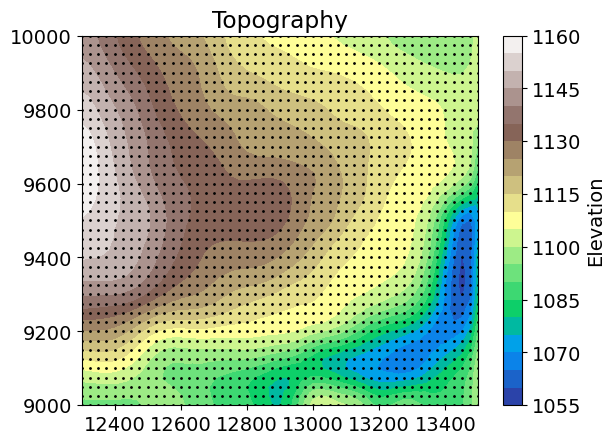

In [5]:
x_topo = topography['X'].values
y_topo = topography['Y'].values
z_topo = topography['Z'].values

topo_xyz = np.c_[x_topo, y_topo, z_topo]

plt.tricontourf(x_topo, y_topo, z_topo, levels=20, cmap="terrain")
plt.colorbar(label="Elevation")
plt.scatter(x_topo, y_topo, c="k", s=1)
plt.title("Topography")
plt.show()

                      

### Define Observation locations

In [6]:
#For a ground survey (like Mt. Milligan), topo and observation locations are the same except spaced out. 
#Sampled every 10 meters, on surface.
x_obs = observations['X'].values
y_obs = observations['Y'].values

fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z_obs = fun_interp(np.c_[x_obs, y_obs])  

# z_obs = LinearNDInterpolator(
#     np.c_[x_topo, y_topo], z_topo
# )(np.c_[x_obs, y_obs])

mask = ~np.isnan(z_obs) #be careful of NANs from the interpolation
receiver_locations = np.c_[x_obs[mask], y_obs[mask], z_obs[mask] + 3] #Add 3 m to avoid tree mesh blowing up 


In [7]:
# Define the component(s) of the field we want to simulate as a list of strings.
# Here we simulation total magnetic intensity data.
components = ["tmi"]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(receiver_locations, components=components) #List of receivers from locations
receiver_list = [receiver_list]

# Define the inducing field
inclination = 75  # inclination [deg]
declination = 25.73  # declination [deg]
amplitude = 58193  # amplitude [nT]

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

 ### Define Tensor Mesh

In [8]:
nx, ny, nz = mesh_data["nx"], mesh_data["ny"], mesh_data["nz"]
dx, dy, dz = mesh_data["dx"], mesh_data["dy"], mesh_data["dz"]
x0, y0, z0 = mesh_data["x0"], mesh_data["y0"], mesh_data["z0"]

x_mesh = [(dx, nx)] #No padding, active cells and ref model mismatch...
y_mesh = [(dy, ny)]
z_mesh = [(dz, nz)]

tensor_mesh = TensorMesh([x_mesh, y_mesh, z_mesh], "CCN")

# Shift origin so that nodes match the UBC mesh definition
tensor_mesh.origin = np.r_[
    x0,              # nodes_x[0] = x0
    y0,              # nodes_y[0] = y0
    z0 - nz * dz,    # nodes_z[0] = z0 - nz*dz, nodes_z[-1] ≈ z0
]

In [9]:
x0

12300.0

### Define active cells

In [10]:
#By active cells, we mean the cells that are below the topography. Air cells should not have a suceptibility value.
# Indices of the active mesh cells from topography (e.g. cells below surface), boolenans
active_cells = active_from_xyz(tensor_mesh, topo_xyz) #simpeg function

 ### Map active cells 

In [11]:
# Define mapping from model to active cells. The model consists of a
# susceptibility value for each cell below the Earth's surface.
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active) #simpeg identity map
model_map2 = maps.InjectActiveCells(tensor_mesh, active_cells, np.nan)

### Define Model

In [12]:
# sus_3d = model.reshape((nx, ny, nz), order="F")
# m_full = sus_3d.ravel(order="F")
# m_active = m_full[active_cells]

# plotting_map = maps.InjectActiveCells(tensor_mesh, active_cells, np.nan)

In [13]:
# # Plot Susceptibility Model
# fig = plt.figure(figsize=(8, 3.5))
# ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])

# norm = mpl.colors.Normalize(vmin=0, vmax=np.max(model))
# mesh.plot_slice(
#     plotting_map * model,
#     normal="Y",
#     ax=ax1,
#     ind=int(mesh.shape_cells[1] / 2),
#     grid=True,
#     pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
# )
# ax1.set_title("Model slice at y = 0 m")
# ax1.set_xlabel("x (m)")
# ax1.set_ylabel("z (m)")

# ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.78])
# cbar = mpl.colorbar.ColorbarBase(
#     ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
# )
# cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

# plt.show()

### Define Forward Simulation

In [14]:
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=tensor_mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

### Define data and errors

In [15]:
dobs_full = observations['MAG'].values
errors_full = observations['ERR'].values
dobs = dobs_full[mask]
errors = errors_full[mask]

# --- NEW BLOCK: detect and drop bad dpred point ---
starting_tensor_model = 1e-4 * np.ones(n_active)

dpred0 = simulation.dpred(starting_tensor_model)
good = ~np.isnan(dpred0)

# Filter receivers and data
receiver_locations_good = receiver_locations[good]
dobs_good = dobs[good]
errors_good = errors[good]

# Rebuild receiver list, source field, survey
receiver_list = magnetics.receivers.Point(
    receiver_locations_good, components=["tmi"]
)
source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=[receiver_list],
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)
survey = magnetics.survey.Survey(source_field)

# Rebuild simulation with cleaned survey
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=tensor_mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

# Replace dobs/errors with cleaned versions
dobs = dobs_good
errors = errors_good
# --- END NEW BLOCK ---

data_object = data.Data(survey, dobs=dobs, standard_deviation=errors)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### Define starting and reference models

In [16]:

starting_tensor_model = 1e-4 * np.ones(n_active)
reference_model = np.zeros_like(starting_tensor_model)
# ref_m = model['sus'].values
# sus_3d = ref_m.reshape((nx, ny, nz), order="F")
# ref_m = sus_3d.ravel(order="F")
# ref_active = ref_m[active_cells]

# Mapping to ignore inactive cells when plotting
tensor_plotting_map = maps.InjectActiveCells(tensor_mesh, active_cells, np.nan)

### Define Regularization

In [17]:
#Using weighted least squares regularization to costrain the rgularization result
regularization_tensor = regularization.WeightedLeastSquares(
    tensor_mesh,
    active_cells=active_cells,
    length_scale_x=1.0,
    length_scale_y=1.0,
    length_scale_z=1.0,
    reference_model= reference_model,
    reference_model_in_smooth=False, #Maybe change to true? check results first
)

### Define Data Misfit

In [18]:
# Using L2 norm of the weighted residual between the observed and predicted data for a given model
data_misfit_tensor = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)

### Define Optimization

In [19]:
optimization_tensor = optimization.ProjectedGNCG(
    maxIter=100, lower=0.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

### Define the inverse Problem

In [20]:
# Full inverse problem definition needs daata misfit, regularization, and optimization objects
inverse_problem_L2 = inverse_problem.BaseInvProblem(data_misfit_tensor, regularization_tensor, optimization_tensor)

### Provide the inversion directives

In [21]:
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

### Define and run Inversion

In [22]:
# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inverse_problem_L2, directives_list)

# Run inversion
recovered_tensor_model = inv_L2.run(starting_tensor_model)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 2008.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  8.71e+03  1.28e+05  7.49e-02  1.28e+05                         0           inf          inf                
   1  8.71e+03  9.99e+04  1.40e+00  1.12e+05    2.97e+05      0      10       3.84e-01     3.79e+05              
   2  4.35e+03  8.19e+04  4.34e+00  1.01e+05    2.17e+05      0      6        8.21e-03     2.21e+03              
   3  2.18e+03  6.18e+04  1.10e+01  8.57e+04    1.61e+05      0      6        7.54e-03     1.22e+03              
   4  1.09e+03  4.28e+04  2.34e+01  6.83e+04    1.34e+05      0      6        8.60e-03     1.15e+03              
   5  5.44e+02  2.78e+04  4.29e+01  5.11e+04    1.07e+05      0      8        4.82e-03 

### Plot Misfit

dpred stats: -329.2071664749936 1314.374780072258 [-329.20716647 -328.6339884  -308.0517032  -278.32940041 -277.05763773
 -272.17864317 -261.46870226 -259.70554978 -259.44102823 -249.05464266]
misfit stats: -232.64540620053603 53.125854198092384


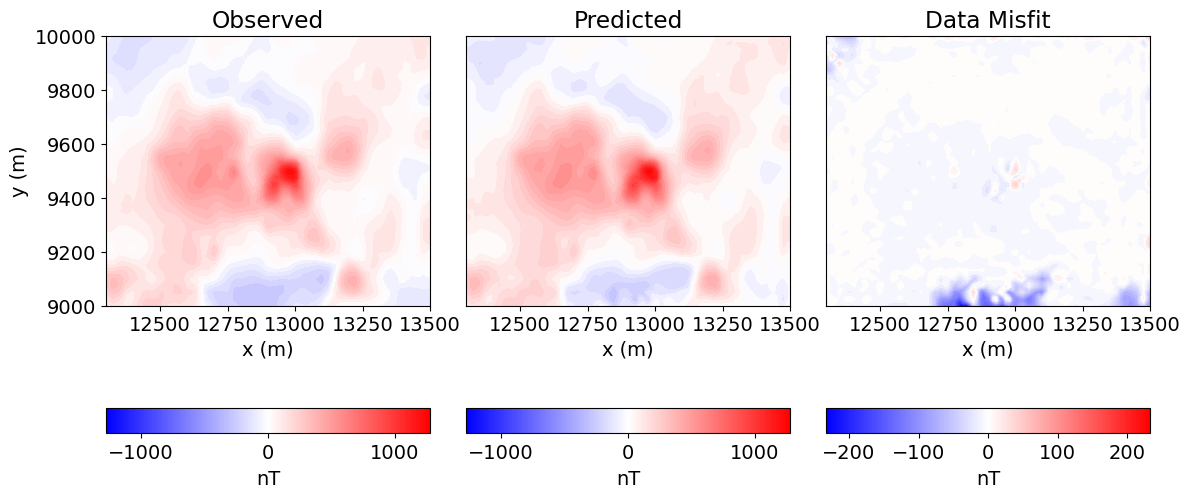

In [23]:
# Predicted data with final recovered model.
dpred_L2 = inverse_problem_L2.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs, dpred_L2, (dobs - dpred_L2)]

print("dpred stats:", np.nanmin(dpred_L2), np.nanmax(dpred_L2), np.unique(dpred_L2)[:10])
print("misfit stats:", np.nanmin(dobs - dpred_L2), np.nanmax(dobs - dpred_L2))


#Sort data?
# idx = np.lexsort((receiver_locations[:,1], receiver_locations[:,0]))

# locs_sorted = receiver_locations[idx]
# data_array_sorted = data_array[idx, :]


fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred_L2))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list.locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

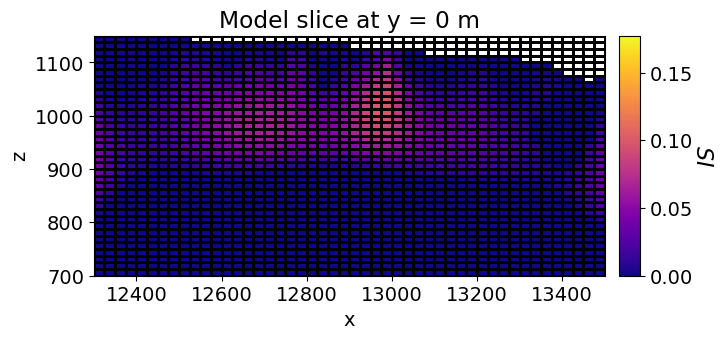

In [24]:
# Plot Recovered Model
fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(
    vmin=np.min(recovered_tensor_model), vmax=np.max(recovered_tensor_model)
)
tensor_mesh.plot_slice(
    tensor_plotting_map * recovered_tensor_model,
    normal="Y",
    ax=ax1,
    ind=int(tensor_mesh.shape_cells[1] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()

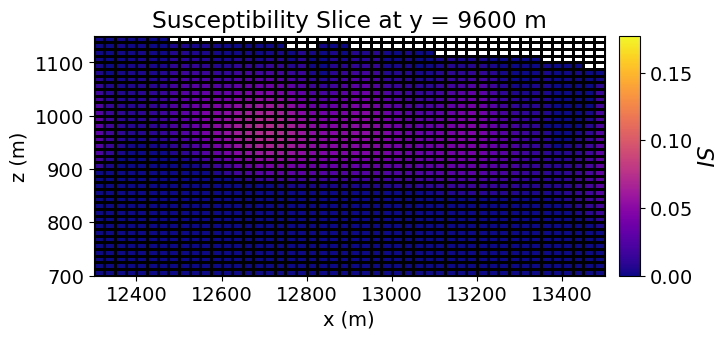

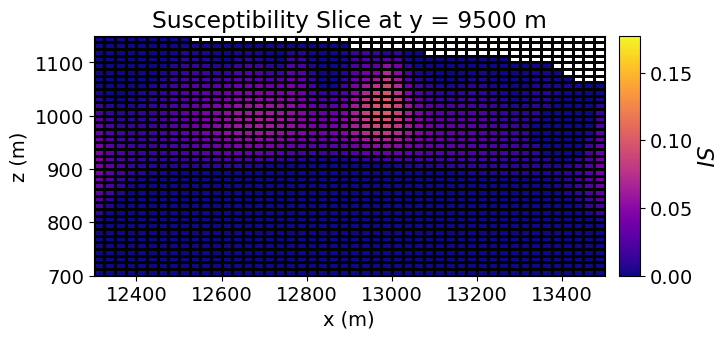

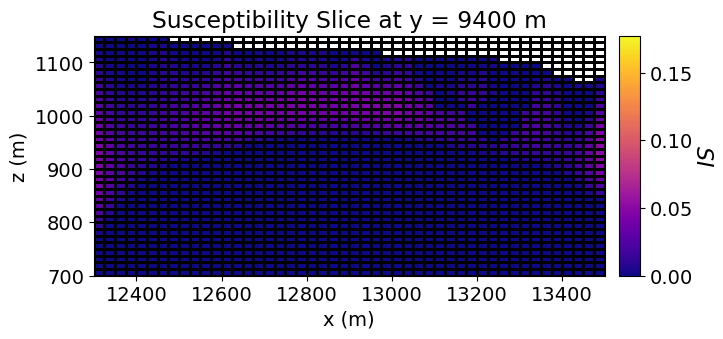

In [25]:
def y_to_index(y_value):
    return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

slice_ys = [9600, 9500, 9400]

full_model = tensor_plotting_map * recovered_tensor_model

for y_val in slice_ys:
    ind = y_to_index(y_val)

    fig = plt.figure(figsize=(7, 3))
    ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

    norm = mpl.colors.Normalize(
        vmin=np.min(recovered_tensor_model),
        vmax=np.max(recovered_tensor_model)
    )

    tensor_mesh.plot_slice(
        full_model,
        normal="Y",
        ax=ax1,
        ind=ind,
        grid=True,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    )

    ax1.set_title(f"Susceptibility Slice at y = {y_val} m")
    ax1.set_xlabel("x (m)")
    ax1.set_ylabel("z (m)")

    ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
    cbar = mpl.colorbar.ColorbarBase(
        ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
    )
    cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

    plt.show()


Didnt use sus.mod... odd
receiver locations lifted + 3m
Need to use IRLS?

### Now use IRLS
Mesh, uncertainties, active cells, model map, starting and refernce models, forward simulation, misfit and optimization are the same.
Regularization and the inversion directions are different

In [27]:
print(mesh_data)

{'nx': 48, 'ny': 40, 'nz': 36, 'x0': 12300.0, 'y0': 9000.0, 'z0': 1150.0, 'dx': 25.0, 'dy': 25.0, 'dz': 12.5}


In [28]:
regularization_irls_tensor = regularization.Sparse(
    tensor_mesh,
    active_cells=active_cells,
    alpha_s= dy**-2,
    alpha_x=1,
    alpha_y=1,
    alpha_z=1,
    reference_model=reference_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

### Define inverse problem

In [29]:
inv_prob_irls = inverse_problem.BaseInvProblem(data_misfit_tensor, regularization_irls_tensor, optimization_tensor)

### Provide inversion directives

In [30]:
sensitivity_weights_irls = directives.UpdateSensitivityWeights(every_iteration=False)
starting_beta_irls = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls = directives.UpdateIRLS(
    cooling_factor=2,
    f_min_change=1e-4,
    max_irls_iterations=25,
    chifact_start=1.0,
)

directives_list_irls = [
    update_irls,
    sensitivity_weights_irls,
    starting_beta_irls,
    update_jacobi_irls,
]


### Define and run inversion 

In [31]:
inv_irls = inversion.BaseInversion(inv_prob_irls, directives_list_irls)
recovered_tensor_irls_model = inv_irls.run(starting_tensor_model)

The callback on the ProjectedGNCG minimizer was replaced.

Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.62e+06  1.28e+05  1.20e-04  1.28e+05                         10       8.49e-01     2.14e+04              
   1  1.62e+06  7.56e+04  1.11e-02  9.35e+04    3.53e+05      0      10       8.79e-03     7.99e+03              
   2  8.11e+05  5.30e+04  2.96e-02  7.70e+04    2.39e+05      0      10       1.53e-02     3.39e+03              
   3  4.05e+05  3.62e+04  5.80e-02  5.97e+04    1.59e+05      0      10       1.01e-02     1.60e+03              
   4  2.03e+05  2.41e+04  9.98e-02  4.43e+04    1.07e+05      0      10       9.19e-03     9.88e+02     

### Plot the data misfit

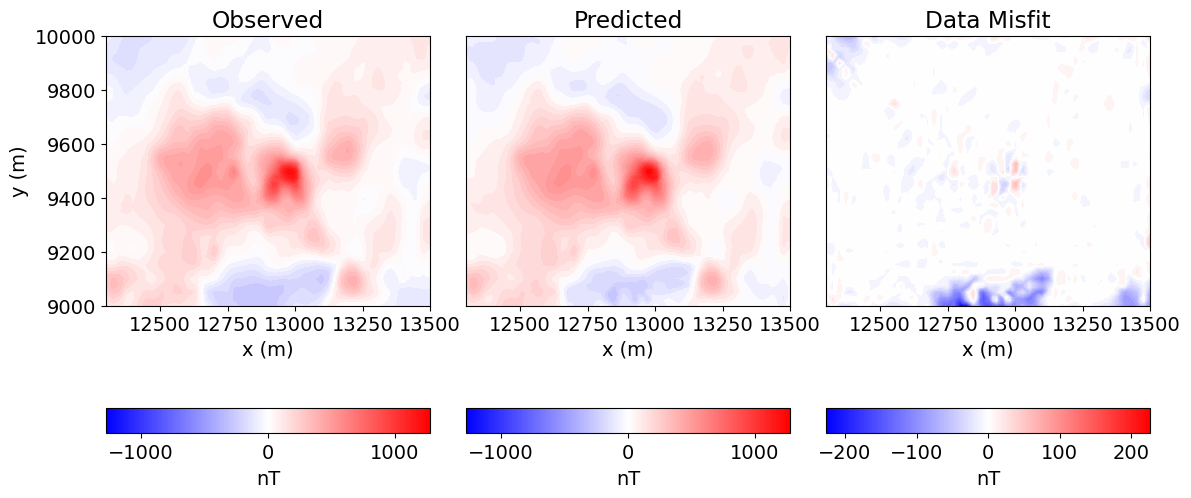

In [34]:
# Predicted data with final recovered model.
dpred_irls = inv_prob_irls.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs, dpred_irls, (dobs - dpred_irls)]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred_irls))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list.locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

### Plot all models

In [35]:
# Recreate True Model on a Tensor Mesh
background_susceptibility = 0.0001
sphere_susceptibility = 0.01

true_model = background_susceptibility * np.ones(n_active)
ind_sphere = model_builder.get_indices_sphere(
    np.r_[0.0, 0.0, 55.0], 16.0, tensor_mesh.cell_centers[active_cells]
)
true_model[ind_sphere] = sphere_susceptibility

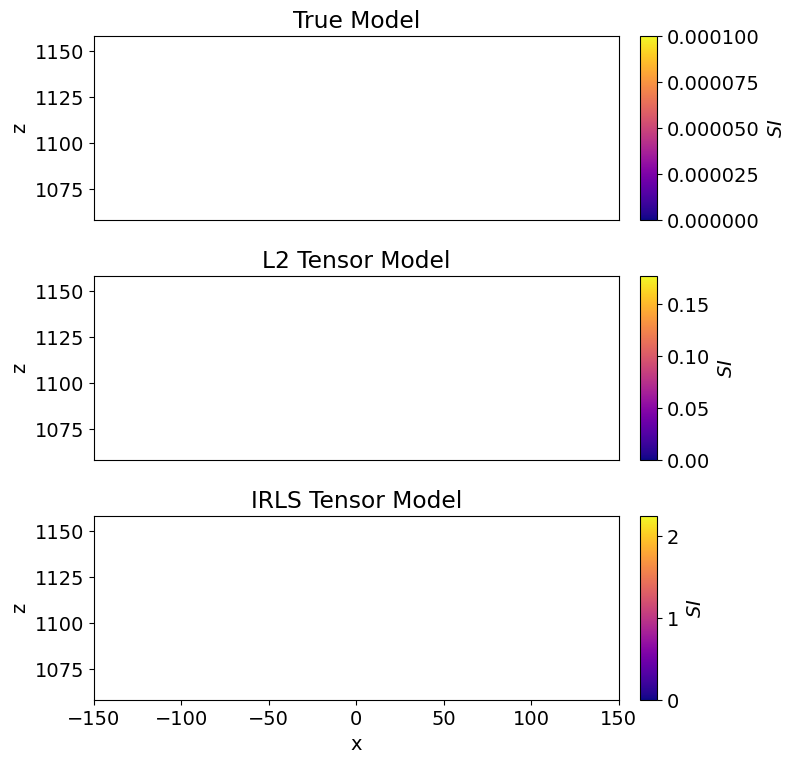

In [37]:
# mesh_list_tree = [tensor_mesh, tensor_mesh, tree_mesh]
# ind_list_tree = [active_cells, active_cells, ind_tree_active]
mesh_list = [tensor_mesh, tensor_mesh, tensor_mesh]
ind_list = [active_cells, active_cells, active_cells]
model_list = [true_model, recovered_tensor_model, recovered_tensor_irls_model]
title_list = ["True Model", "L2 Tensor Model", "IRLS Tensor Model"]
cplot = 3 * [None]
cbar = 3 * [None]
norm = 3 * [None]

fig = plt.figure(figsize=(7, 8))
ax1 = [fig.add_axes([0.1, 0.7 - 0.3 * ii, 0.75, 0.23]) for ii in range(0, 3)]
ax2 = [fig.add_axes([0.88, 0.7 - 0.3 * ii, 0.025, 0.23]) for ii in range(0, 3)]

for ii, mesh in enumerate(mesh_list):
    plotting_map = maps.InjectActiveCells(mesh, ind_list[ii], np.nan)
    max_abs = np.max(np.abs(model_list[ii]))
    norm[ii] = mpl.colors.Normalize(vmin=0.0, vmax=max_abs)

    cplot[ii] = mesh.plot_slice(
        plotting_map * model_list[ii],
        normal="Y",
        ax=ax1[ii],
        ind=int(mesh.shape_cells[1] / 2),
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm[ii]},
    )
    ax1[ii].set_xlim([-150, 150])
    ax1[ii].set_ylim([topo_xyz[:, -1].max() - 100, topo_xyz[:, -1].max()])
    if ii < 2:
        ax1[ii].set_xlabel("")
        ax1[ii].set_xticks([])
    ax1[ii].set_title(title_list[ii])

    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="vertical", cmap=mpl.cm.plasma
    )
    cbar[ii].set_label("$SI$", labelpad=5)

# Use sus.mod to compare results